In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../processed_data/cmi_preprocessed.csv")
print(df.head())

   Unnamed: 0  Basic_Demos-Age  Basic_Demos-Sex  CGAS-CGAS_Score  \
0           0              5.0                0             51.0   
1           1              9.0                0             60.5   
2           2             10.0                1             71.0   
3           3              9.0                0             71.0   
4           4             18.0                1             65.0   

   Physical-Height  Physical-Weight  Physical-HeartRate  \
0       116.840000        23.042474           84.333333   
1       121.920000        20.865232           70.000000   
2       143.510000        34.291555           94.000000   
3       142.240000        37.013107           97.000000   
4       137.862733        34.926584           89.000000   

   BIA-BIA_Activity_Level_num  BIA-BIA_BMI  BIA-BIA_DEE  BIA-BIA_FFM  \
0                         2.0      16.8792      1492.00      41.5862   
1                         2.0      14.0371      1498.65      42.0291   
2                   

In [38]:
cols_to_keep = ["Basic_Demos-Age", "CGAS-CGAS_Score", "Physical-Height", "Physical-HeartRate", "BIA-BIA_BMI",
"BIA-BIA_DEE", "BIA-BIA_FFMI", "BIA-BIA_FMI", "Physical-Mean_arterial_pressure", "PAQ_Combined"]
df_outlier_detection = df[cols_to_keep]

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df_outlier_detection)

In [40]:
from pyod.models.abod import ABOD
clf = ABOD(contamination=0.01)
clf.fit(X)

,contamination,0.01
,n_neighbors,5
,method,'fast'
,algorithm,'auto'
,leaf_size,30
,metric,'minkowski'
,p,2
,metric_params,None
,n_jobs,1


In [41]:
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8176,   83]))

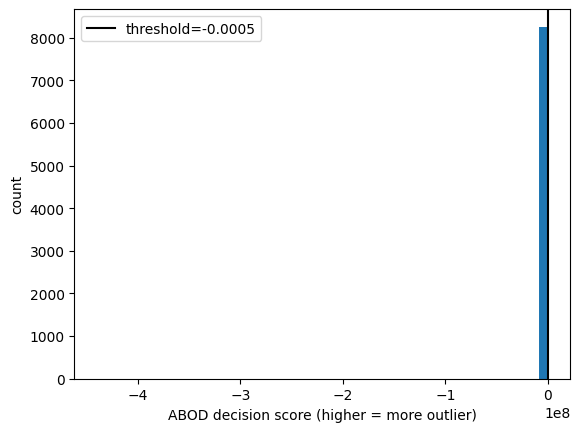

In [42]:
plt.hist(clf.decision_scores_, bins=50)
plt.axvline(clf.threshold_, c='k', label=f'threshold={clf.threshold_:.4f}')
plt.xlabel('ABOD decision score (higher = more outlier)')
plt.ylabel('count')
plt.legend()
plt.show()

In [43]:
df_outlier_detection['anomaly_score'] = clf.decision_scores_
df_outlier_detection['is_outlier'] = clf.labels_

outliers = df_outlier_detection[df_outlier_detection['is_outlier'] == 1]
print(f"outliers: {len(outliers)} / {len(df_outlier_detection)}")

df_outlier_detection.sort_values(by='anomaly_score', ascending=False).head(10)

outliers: 83 / 8259


,Basic_Demos-Age,CGAS-CGAS_Score,Physical-Height,Physical-HeartRate,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFMI,BIA-BIA_FMI,Physical-Mean_arterial_pressure,PAQ_Combined,anomaly_score,is_outlier
3539,13.0,65.0,139.700000,81.0,17.966500,1863.980000,14.092500,3.698630,83.333333,2.275000,-0.000000e+00,1
3811,13.0,65.0,139.700000,81.0,17.966500,1863.980000,14.092500,3.698630,83.333333,2.275000,-0.000000e+00,1
1163,13.0,65.0,139.700000,81.0,17.966500,1863.980000,14.092500,3.698630,83.333333,2.275000,-0.000000e+00,1
1555,13.0,65.0,136.889067,81.0,17.142549,1863.980000,13.878769,3.047066,83.333333,2.273333,-7.888609e-31,1
6143,16.0,49.0,177.342800,87.5,20.548077,124728.000000,17.574909,16.920504,119.666667,2.666667,-2.301949e-07,1
5346,10.0,71.5,152.323800,68.0,18.078301,124728.000000,14.142175,4.886692,76.166667,2.000000,-5.568038e-07,1
5509,13.0,55.5,166.954200,70.5,21.561823,80961.750842,15.292535,4.830934,80.666667,2.500000,-2.757493e-06,1
4164,6.0,60.5,171.551600,96.5,22.386308,11248.196197,16.761603,10.040451,87.666667,2.500000,-9.361185e-06,1
3428,6.0,65.0,105.410000,106.0,48.375400,1607.800000,20.123900,28.251500,88.000000,2.185000,-9.648553e-06,1
4510,6.0,57.5,131.800600,99.0,17.916796,1378.138529,13.916357,9.996506,106.166667,2.596667,-1.136657e-05,1


In [44]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(df)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f"Explained variance — PC1: {ev[0]:.2%}, PC2: {ev[1]:.2%}")
print(f"Cumulative (2 PCs): {ev.sum():.2%}")

Explained variance — PC1: 24.39%, PC2: 6.90%
Cumulative (2 PCs): 31.29%


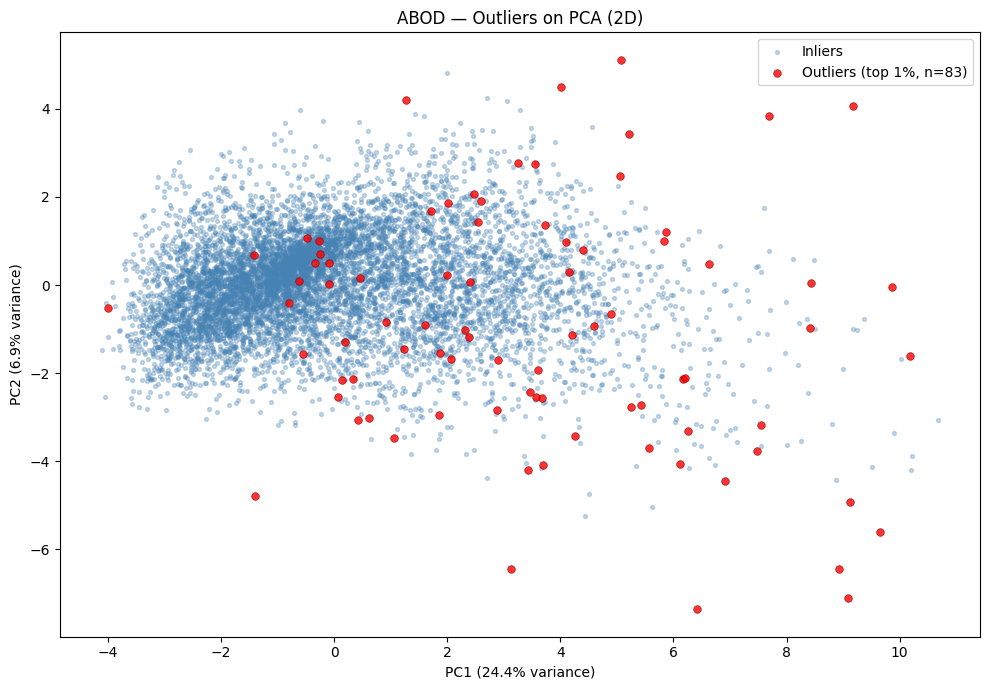

In [45]:
outlier_mask = clf.labels_ == 1
n_outliers = outlier_mask.sum()

fig, ax = plt.subplots(figsize=(10, 7))

inliers = ~outlier_mask
ax.scatter(X_pca[inliers, 0], X_pca[inliers, 1],
           c="steelblue", s=8, alpha=0.3, label="Inliers")
ax.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
           c="red", s=30, alpha=0.8, edgecolors="darkred", linewidths=0.5,
           label=f"Outliers (top 1%, n={n_outliers})")

ax.set_xlabel(f"PC1 ({ev[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({ev[1]:.1%} variance)")
ax.set_title("ABOD — Outliers on PCA (2D)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_outlier_detection.to_csv('../outlier_data/abod.csv')